# Population-level TR distributions by novelty class (full 67-genome cohort)

Same analysis as `docs/figures/population_distributions_full67.md`
(generated by `src/python/reporting/population_report.py`), as a notebook.

Source: `05_hprc_multisample.tsv`, the full-genome `sv_trfcaller` + `novelty
annotate` output for the 67 HPRC genomes. Not checked into this repo (large
per-sample dump) -- point `MULTISAMPLE_TSV` below at your own copy.

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

MULTISAMPLE_TSV = "/Users/liedeweivandevondel/Documents/Work/Experiments_Miami/BCM_hackathon/05_hprc_multisample.tsv"

# Palette matches notebooks/novel_tr_results.ipynb and docs/figures/*.md so
# every report in this repo reads as one system: one novelty class, one
# colour, everywhere.
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
CLASSES = ["known", "novel_motif", "novel_locus"]
NOVEL_CLASSES = ["novel_motif", "novel_locus"]
CLASS_COLOR = {"known": "#2a78d6", "novel_motif": "#eb6834", "novel_locus": "#1baf7a"}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 120, "font.size": 9.5, "font.family": "sans-serif",
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.grid": True, "axes.axisbelow": True, "legend.frameon": False,
})

## Load and de-duplicate

`sv_trfcaller.py` currently double-emits every repeat call for
homozygous-alt genotypes (exact duplicate rows, not distinct repeat
regions -- see `issue_duplicate_rows.md`). Any per-row statistic (purity,
motif length, GC content) would otherwise silently double-weight
homozygous-alt calls, so we drop exact duplicates before computing
anything.

In [2]:
def gc_content(motif: str) -> float:
    """Fraction of G/C bases in the repeat motif itself, in [0, 1]."""
    if not motif:
        return float("nan")
    return (motif.count("G") + motif.count("C")) / len(motif)


df = pd.read_csv(MULTISAMPLE_TSV, sep="\t", low_memory=False)
n_before = len(df)
df = df.drop_duplicates()
print(f"dropped {n_before - len(df):,} exact-duplicate rows ({100 * (n_before - len(df)) / n_before:.1f}%) "
      f"from homozygous-alt double-emission")

df["gc_content"] = df["motif"].astype(str).apply(gc_content)

n_loci = df.groupby(["chrom", "ins_coord"]).ngroups
print(f"{len(df):,} TRF calls across {n_loci:,} loci (locus = chrom+position, not SVID -- "
      f"see docs/figures/novelty_by_allele_count.md for why)")

dropped 58,964 exact-duplicate rows (26.6%) from homozygous-alt double-emission
162,441 TRF calls across 17,270 loci (locus = chrom+position, not SVID -- see docs/figures/novelty_by_allele_count.md for why)


## Summary

In [3]:
rows = []
for cls in CLASSES:
    sub = df[df["novelty"] == cls]
    rows.append({
        "novelty": cls,
        "n": len(sub),
        "%": f"{100 * len(sub) / len(df):.1f}%",
        "median motif_length": sub["motif_length"].median(),
        "median rep_length": sub["rep_length"].median(),
        "median purity": round(sub["purity"].median(), 3),
        "median gc_content": round(sub["gc_content"].median(), 3),
    })
summary = pd.DataFrame(rows).set_index("novelty")
summary

,n,%,median motif_length,median rep_length,median purity,median gc_content
novelty,,,,,,
known,126524,77.9%,4.0,147.0,0.887,0.250
novel_motif,34490,21.2%,22.0,306.0,0.906,0.226
novel_locus,1427,0.9%,5.0,94.0,0.879,0.188


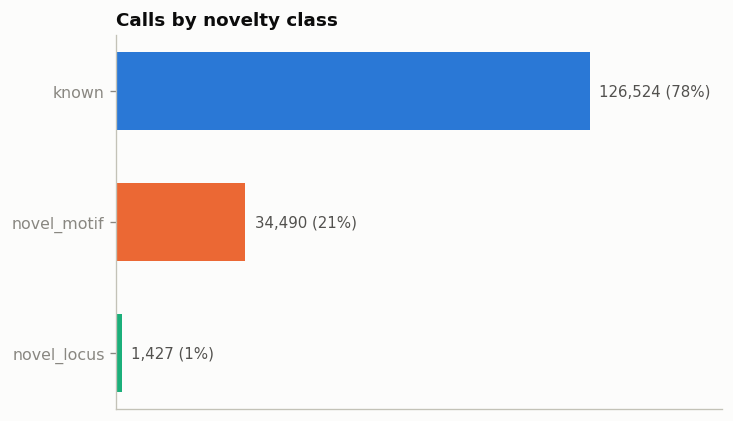

In [4]:
counts = df["novelty"].value_counts().reindex(CLASSES)
fig, ax = plt.subplots(figsize=(6.0, 3.4), constrained_layout=True)
ax.barh(CLASSES[::-1], counts[CLASSES[::-1]], height=0.6, color=[CLASS_COLOR[c] for c in CLASSES[::-1]])
for i, cls in enumerate(CLASSES[::-1]):
    ax.text(counts[cls] + counts.max() * 0.02, i, f"{counts[cls]:,} ({100 * counts[cls] / counts.sum():.0f}%)",
            va="center", fontsize=9, color=INK_2)
ax.set_title("Calls by novelty class", loc="left", fontsize=11, fontweight="semibold")
ax.set_xlim(0, counts.max() * 1.28)
ax.set_xticks([])
ax.grid(False)
plt.show()

## Distributions: `novel_motif` vs `novel_locus`

`known` is excluded from the charts below (not of interest here). Shown as
raw counts, not density -- the two classes differ substantially in size, so
absolute magnitude matters, not just shape. Where a fixed axis range would
silently drop overflow values, they are pooled into a labelled `<cap>+`
bucket instead and called out with an annotation.

In [5]:
def plot_novel_distribution(column, ax_label, title, binwidth=None, cap=None, discrete=False):
    d = df[df["novelty"].isin(NOVEL_CLASSES)]
    plot_col = column
    overflow_n = 0
    if cap is not None:
        overflow_n = int((d[column] >= cap).sum())
        plot_col = f"{column}__capped"
        d = d.assign(**{plot_col: d[column].clip(upper=cap)})

    fig, ax = plt.subplots(figsize=(7.2, 3.6), constrained_layout=True)
    hist_kwargs = dict(
        data=d, x=plot_col, hue="novelty", hue_order=NOVEL_CLASSES, palette=CLASS_COLOR,
        stat="count", element="step", fill=True, alpha=0.4, multiple="layer", ax=ax,
    )
    if discrete:
        hist_kwargs["discrete"] = True
    else:
        hist_kwargs["binwidth"] = binwidth
        if cap is not None:
            hist_kwargs["binrange"] = (0, cap + binwidth)
    sns.histplot(**hist_kwargs)

    ax.set_title(title, loc="left", fontsize=11, fontweight="semibold")
    ax.set_xlabel(ax_label)
    ax.set_ylabel("Count")
    if discrete and cap is not None:
        ticks = list(range(1, int(cap) + 1, 2))
        labels = [str(t) for t in ticks]
        labels[-1] = f"{int(cap)}+"
        ax.set_xticks(ticks, labels)
    if overflow_n:
        ax.text(0.98, 0.72, f"{overflow_n:,} calls ({overflow_n / len(d):.1%}) pooled at {int(cap)}+\n"
                f"(actual values up to {d[column].max():,.0f})",
                transform=ax.transAxes, ha="right", fontsize=8, color=INK_2)
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("novelty")
    plt.show()

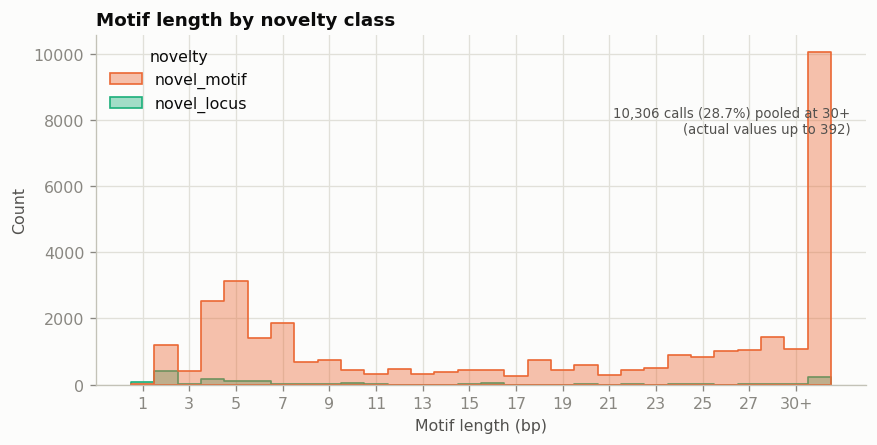

In [6]:
plot_novel_distribution("motif_length", "Motif length (bp)", "Motif length by novelty class", cap=30, discrete=True)

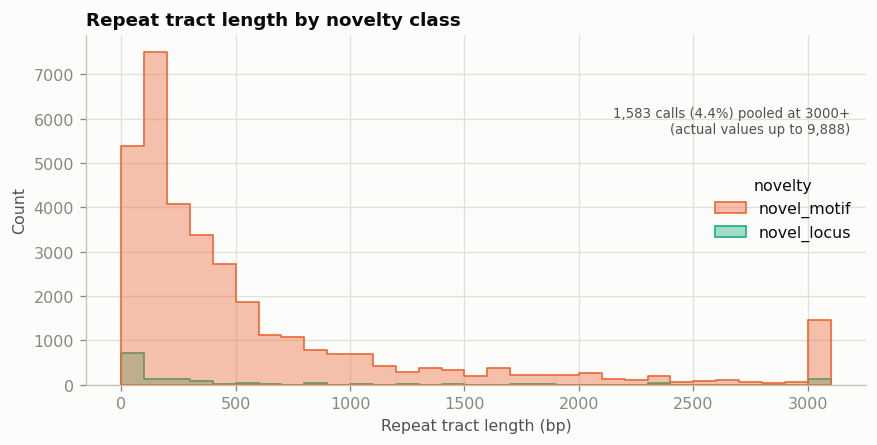

In [7]:
plot_novel_distribution("rep_length", "Repeat tract length (bp)", "Repeat tract length by novelty class", binwidth=100, cap=3000)

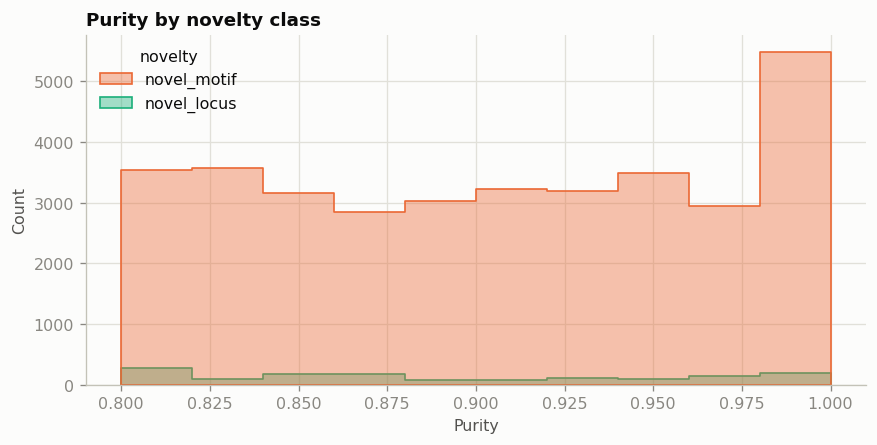

In [8]:
plot_novel_distribution("purity", "Purity", "Purity by novelty class", binwidth=0.02)

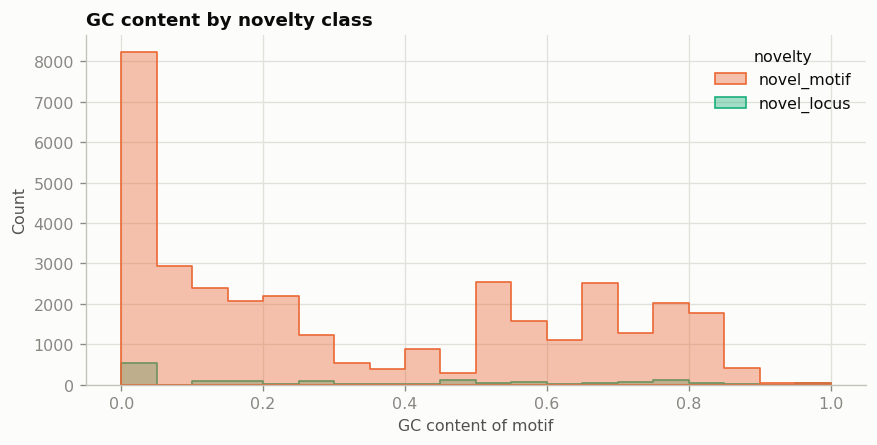

In [9]:
plot_novel_distribution("gc_content", "GC content of motif", "GC content by novelty class", binwidth=0.05)